## V-Columns, Identity Block & Preprocessing Decisions Table

Final EDA notebook — summarises all preprocessing decisions made across commits 2, 3, 4.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR      = '../data/raw'
PROCESSED_DIR = '../data/processed'

txn = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
idn = pd.read_csv(f'{DATA_DIR}/train_identity.csv')
df  = txn.merge(idn, on='TransactionID', how='left')

fraud_rate = df['isFraud'].mean()
print(f'Loaded {df.shape[0]:,} rows | fraud rate: {fraud_rate*100:.2f}%')

Loaded 590,540 rows | fraud rate: 3.50%


---
## 7. V-Columns Analysis

In [3]:
v_cols = [c for c in df.columns if c.startswith('V')]
print(f'Total V-columns : {len(v_cols)}')
print(f'V-cols null pct : min={df[v_cols].isnull().mean().min()*100:.1f}%  max={df[v_cols].isnull().mean().max()*100:.1f}%')

# Correlation with isFraud
v_corr = df[v_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)
print(f'\nTop 10 V-cols by |correlation| with isFraud:')
print(v_corr.head(10).to_string())

Total V-columns : 339
V-cols null pct : min=0.0%  max=86.1%

Top 10 V-cols by |correlation| with isFraud:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832


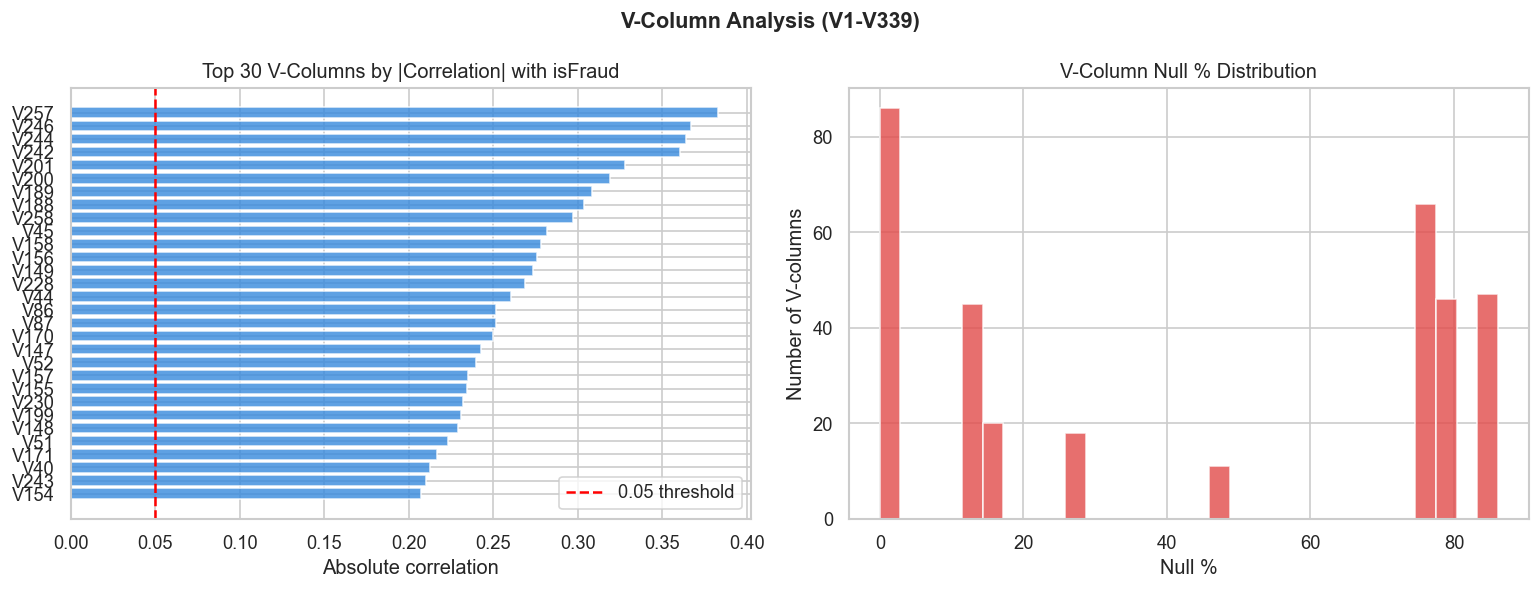

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Top 30 V-cols by correlation
top30 = v_corr.head(30)
axes[0].barh(top30.index[::-1], top30.values[::-1], color='#378ADD', alpha=0.8)
axes[0].set_title('Top 30 V-Columns by |Correlation| with isFraud')
axes[0].set_xlabel('Absolute correlation')
axes[0].axvline(x=0.05, color='red', linestyle='--', label='0.05 threshold')
axes[0].legend()

# Null % distribution for V-cols
v_null_pct = df[v_cols].isnull().mean() * 100
axes[1].hist(v_null_pct, bins=30, color='#E24B4A', alpha=0.8, edgecolor='white')
axes[1].set_title('V-Column Null % Distribution')
axes[1].set_xlabel('Null %')
axes[1].set_ylabel('Number of V-columns')

plt.suptitle('V-Column Analysis (V1-V339)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/fig_06_v_columns.png', bbox_inches='tight')
plt.show()

In [5]:
# V-column null groups — nulls appear in groups (Vesta feature blocks)
v_null_pattern = df[v_cols].isnull().mean().round(2)
null_groups = v_null_pattern.value_counts().head(10)
print('Most common null % patterns in V-columns:')
print('(Same null % = same Vesta feature block)')
print(null_groups.to_string())

Most common null % patterns in V-columns:
(Same null % = same Vesta feature block)
0.00    86
0.76    66
0.86    47
0.78    46
0.13    45
0.15    20
0.29    18
0.47    11


**→ Preprocessing decision:**  
- V-columns null in **groups** — same Vesta feature block either fires or doesn't  
- Fill nulls with `0` not `-999` — `0` means feature absent, XGBoost misreads `-999` as extreme outlier  
- Keep ALL V-columns — top ones have |correlation| > 0.1 with fraud, XGBoost will select the best  
- Do NOT drop V-columns just because they have high null % — null pattern itself is informative

---
## 8. Identity Block Analysis

In [6]:
id_num_cols = [f'id_{str(i).zfill(2)}' for i in range(1, 12) if f'id_{str(i).zfill(2)}' in df.columns]
id_cat_cols = [f'id_{str(i).zfill(2)}' for i in range(12, 39) if f'id_{str(i).zfill(2)}' in df.columns]

print(f'Numeric identity cols  : {len(id_num_cols)} → {id_num_cols}')
print(f'Categorical identity cols: {len(id_cat_cols)} → {id_cat_cols[:8]}...')

# Null % per id column
print('\nNull % for numeric identity cols:')
for col in id_num_cols:
    null_pct   = df[col].isnull().mean() * 100
    fraud_null = df[df[col].isnull()]['isFraud'].mean() * 100
    fraud_pres = df[df[col].notnull()]['isFraud'].mean() * 100
    print(f'  {col}: null={null_pct:.0f}%  fraud_when_null={fraud_null:.1f}%  fraud_when_present={fraud_pres:.1f}%')

Numeric identity cols  : 11 → ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11']
Categorical identity cols: 27 → ['id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19']...

Null % for numeric identity cols:
  id_01: null=76%  fraud_when_null=2.1%  fraud_when_present=7.8%
  id_02: null=76%  fraud_when_null=2.1%  fraud_when_present=8.0%
  id_03: null=89%  fraud_when_null=2.6%  fraud_when_present=10.7%
  id_04: null=89%  fraud_when_null=2.6%  fraud_when_present=10.7%
  id_05: null=77%  fraud_when_null=2.1%  fraud_when_present=8.0%
  id_06: null=77%  fraud_when_null=2.1%  fraud_when_present=8.0%
  id_07: null=99%  fraud_when_null=3.5%  fraud_when_present=8.3%
  id_08: null=99%  fraud_when_null=3.5%  fraud_when_present=8.3%
  id_09: null=87%  fraud_when_null=2.5%  fraud_when_present=10.4%
  id_10: null=87%  fraud_when_null=2.5%  fraud_when_present=10.4%
  id_11: null=76%  fraud_when_null=2.1%  fraud_when_present=8.0%


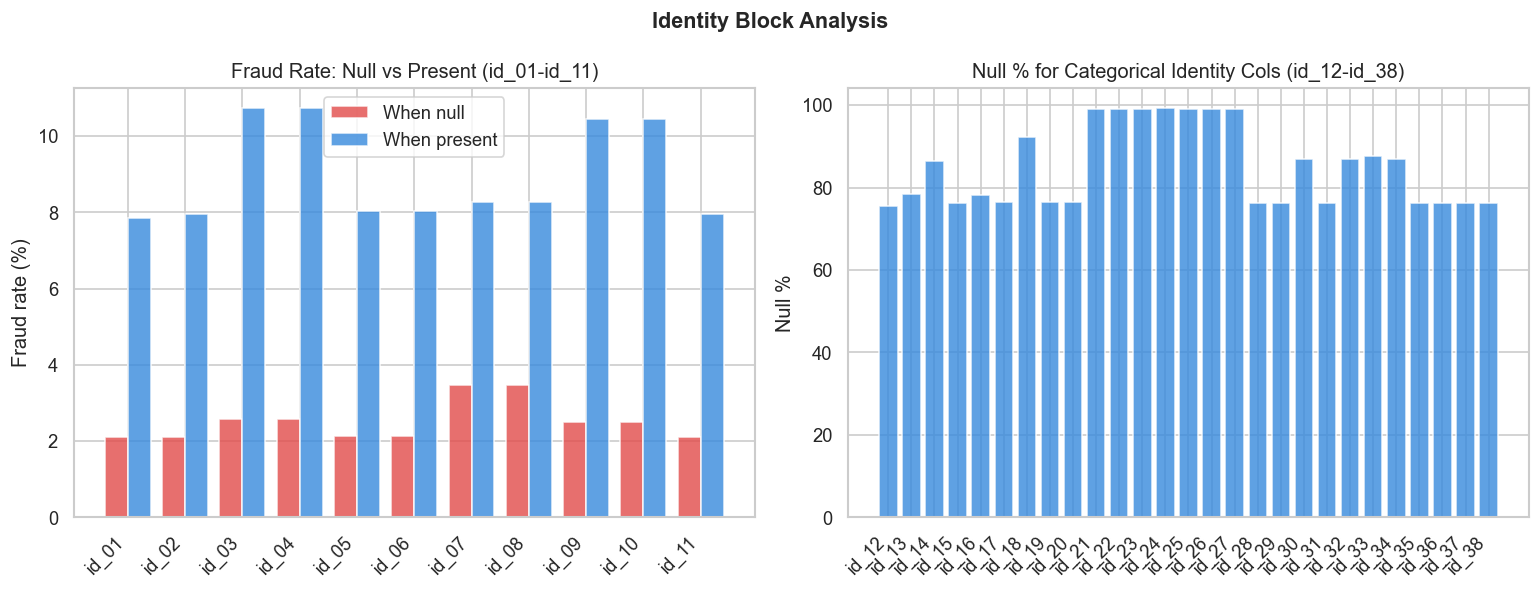

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Fraud rate: null vs present for id numeric cols
fraud_null_rates    = []
fraud_present_rates = []
for col in id_num_cols:
    fraud_null_rates.append(df[df[col].isnull()]['isFraud'].mean() * 100)
    fraud_present_rates.append(df[df[col].notnull()]['isFraud'].mean() * 100)

x = np.arange(len(id_num_cols))
axes[0].bar(x - 0.2, fraud_null_rates,    0.4, label='When null',    color='#E24B4A', alpha=0.8)
axes[0].bar(x + 0.2, fraud_present_rates, 0.4, label='When present', color='#378ADD', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(id_num_cols, rotation=45, ha='right')
axes[0].set_title('Fraud Rate: Null vs Present (id_01-id_11)')
axes[0].set_ylabel('Fraud rate (%)')
axes[0].legend()

# Categorical id cols null %
id_cat_null = df[id_cat_cols].isnull().mean() * 100
axes[1].bar(id_cat_cols, id_cat_null.values, color='#378ADD', alpha=0.8)
axes[1].set_title('Null % for Categorical Identity Cols (id_12-id_38)')
axes[1].set_ylabel('Null %')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Identity Block Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/fig_07_identity_block.png', bbox_inches='tight')
plt.show()

**→ Preprocessing decision:**  
- `id_01..id_11` (numeric): fill `-1` + add `id_XX_missing` binary flag per column  
- `id_12..id_38` (categorical): fill `'unknown'` + label encode  
- Create `has_identity` — single flag capturing whether identity block exists at all  
- Missingness in identity cols is NOT random — fraudsters avoid leaving device traces

---
## 9. Final Preprocessing Decisions Table

In [8]:
decisions = [
    {
        'Column Group':       'V1-V339',
        'Strategy':           'Fill null → 0',
        'Reason':             'Null = feature not triggered, not unknown. -999 misleads XGBoost.'
    },
    {
        'Column Group':       'id_01..id_11 (numeric)',
        'Strategy':           'Fill → -1 + _missing flag',
        'Reason':             'Null is informative — fraudsters skip identity. Flag preserves signal.'
    },
    {
        'Column Group':       'id_12..id_38 (categorical)',
        'Strategy':           'Fill → unknown + label encode',
        'Reason':             'Categorical — unknown is a valid category, not missing data.'
    },
    {
        'Column Group':       'card1, card2, card3, card5',
        'Strategy':           'Fill → median',
        'Reason':             'Numeric card attributes — median avoids outlier distortion.'
    },
    {
        'Column Group':       'card1, card2, addr1, addr2',
        'Strategy':           'Frequency encode',
        'Reason':             'High cardinality — freq count captures velocity signal without OHE explosion.'
    },
    {
        'Column Group':       'ProductCD, card4, card6, email domains',
        'Strategy':           'Fill unknown + label encode',
        'Reason':             'Low cardinality categoricals — label encode sufficient for tree models.'
    },
    {
        'Column Group':       'M1-M9 (match flags)',
        'Strategy':           'Fill unknown + label encode',
        'Reason':             'T/F/null all carry different signal — null ≠ F.'
    },
    {
        'Column Group':       'TransactionAmt',
        'Strategy':           'log1p + decimal + cents + is_round',
        'Reason':             'Right-skewed. Decimal and round-number patterns correlate with fraud.'
    },
    {
        'Column Group':       'TransactionDT',
        'Strategy':           'Extract hour, day_of_week, is_night, is_weekend → drop raw',
        'Reason':             'Raw seconds meaningless. Time-of-day patterns directly predictive.'
    },
    {
        'Column Group':       'Identity block presence',
        'Strategy':           'Create has_identity binary flag',
        'Reason':             'Missing identity = 2x fraud rate. Single flag captures this signal.'
    },
]

decisions_df = pd.DataFrame(decisions)
print(decisions_df.to_string(index=False))

                          Column Group                                                   Strategy                                                                        Reason
                               V1-V339                                              Fill null → 0             Null = feature not triggered, not unknown. -999 misleads XGBoost.
                id_01..id_11 (numeric)                                  Fill → -1 + _missing flag        Null is informative — fraudsters skip identity. Flag preserves signal.
            id_12..id_38 (categorical)                              Fill → unknown + label encode                  Categorical — unknown is a valid category, not missing data.
            card1, card2, card3, card5                                              Fill → median                   Numeric card attributes — median avoids outlier distortion.
            card1, card2, addr1, addr2                                           Frequency encode High cardinality — fre

In [9]:
# Save feature groups for reference in preprocess.py
feature_groups = {
    'v_cols':       [f'V{i}' for i in range(1, 340)],
    'id_num_cols':  [f'id_{str(i).zfill(2)}' for i in range(1, 12)],
    'id_cat_cols':  [f'id_{str(i).zfill(2)}' for i in range(12, 39)],
    'cat_cols':     ['ProductCD','card4','card6','P_emaildomain','R_emaildomain',
                     'M1','M2','M3','M4','M5','M6','M7','M8','M9'],
    'freq_cols':    ['card1','card2','addr1','addr2'],
    'drop_cols':    ['TransactionID','TransactionDT'],
}

with open(f'{PROCESSED_DIR}/feature_groups.json', 'w') as f:
    json.dump(feature_groups, f, indent=2)

decisions_df.to_csv(f'{PROCESSED_DIR}/preprocessing_decisions.csv', index=False)

print('Saved:')
print(f'  {PROCESSED_DIR}/feature_groups.json')
print(f'  {PROCESSED_DIR}/preprocessing_decisions.csv')

Saved:
  ../data/processed/feature_groups.json
  ../data/processed/preprocessing_decisions.csv


---
## EDA Summary

| Finding | Impact on Model |
|---|---|
| 3.5% fraud rate (28:1) | Use `scale_pos_weight=28`, Average Precision as metric |
| Amount is right-skewed | log1p transform |
| Night transactions riskier | `is_night` binary feature |
| Missing identity = 2x fraud | `has_identity` flag + per-col `_missing` flags |
| V-cols null in groups | Fill 0, keep all, let XGBoost select |
| High-cardinality card/addr | Frequency encoding (computed on train only) |
| M-flag null ≠ False | Fill `unknown`, treat as separate category |

**Next step:** `src/preprocess.py` implements all decisions from this table.

---